**Anopheles albimanus Midgut Microbiome and Its Association with Insecticide Resistance**

# **Phase 1:** Environment & Project Setup
**Step 1:** Initialize Google Colab Environment & Mount Google Drive
Mount your Google Drive so downloaded sequence data, cleaned files, and generated tables persist even if Colab disconnects.

In [2]:
# Step 1: Mount Google Drive (for saving final results only)
from google.colab import drive
import os

drive.mount('/content/drive')

# IMPORTANT: all heavy intermediate files (raw reads, reference genome, Kraken2 DB,
# ~9-10 GB total) are written to Colab's LOCAL disk, not Drive. Colab's local disk is
# much bigger than a typical free Drive quota and it costs nothing against your Drive
# storage. Only the small final result files (a few MB of CSVs/PNGs) get copied to
# Drive at the end, in the "Sync Results to Google Drive" cell.
project_dir = '/content/AMR_Albimanus_Work'
drive_results_dir = '/content/drive/MyDrive/Anopheles_Microbiome_Project/results'

os.makedirs(project_dir, exist_ok=True)
os.chdir(project_dir)
print(f"Current working directory (LOCAL disk, not Drive): {os.getcwd()}")
print(f"Final results will be synced to Drive at: {drive_results_dir}")


Mounted at /content/drive
Current working directory (LOCAL disk, not Drive): /content/AMR_Albimanus_Work
Final results will be synced to Drive at: /content/drive/MyDrive/Anopheles_Microbiome_Project/results


# **Step 2:** Install Bioinformatic Tools & Dependencies
Install command-line tools (sra-toolkit, bwa, samtools, fastp) and Python packages directly into the Colab Linux container.

In [3]:
# Step 2: Install required tools
!apt-get update -qq
!apt-get install -y sra-toolkit bwa samtools fastp

# Install Python packages
!pip install biopython pandas matplotlib seaborn scikit-bio

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  blends-common libhts3 libhtscodecs2 libkdf5-2 libncbi-vdb2 libncbi-wvdb2
  med-config menu
Suggested packages:
  blends-doc menu-l10n gksu | kde-runtime | ktsuss cwltool
The following NEW packages will be installed:
  blends-common bwa fastp libhts3 libhtscodecs2 libkdf5-2 libncbi-vdb2
  libncbi-wvdb2 med-config menu samtools sra-toolkit
0 upgraded, 12 newly installed, 0 to remove and 25 not upgraded.
Need to get 9,641 kB of archives.
After this operation, 26.4 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 menu amd64 2.1.47ubuntu4 [354 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd

In [4]:
!which bwa samtools

/usr/bin/bwa
/usr/bin/samtools


# **Phase 2:** Data Acquisition & Preprocessing
**Step 3:** Download Metadata & Fetch Raw Sequences
Fetch sample run accessions from PRJNA388280 (An. albimanus / Fenitrothion).


In [6]:
# Install Entrez Direct (needed for the esearch/efetch calls in the next two cells)
!sh -c "$(curl -fsSL https://ftp.ncbi.nlm.nih.gov/entrez/entrezdirect/install-edirect.sh)" 2>/dev/null
import os
os.environ["PATH"] += os.pathsep + os.path.expanduser("~/edirect")



Entrez Direct has been successfully downloaded and installed.

In order to complete the configuration process, please execute the following:

  echo "export PATH=/root/edirect:\${PATH}" >> ${HOME}/.bashrc

or manually edit the PATH variable assignment in your .bashrc file.

Would you like to do that automatically now? [y/N]
y
OK, done.

To activate EDirect for this terminal session, please execute the following:

export PATH=${HOME}/edirect:${PATH}



In [7]:
import pandas as pd
import subprocess

# FIXED: the old trace.ncbi.nlm.nih.gov/.../sra-db-be.cgi?rettype=runinfo endpoint is a
# legacy, frequently-broken API (NCBI has changed/removed it more than once). Entrez
# Direct's esearch|efetch is the currently supported way to pull a RunInfo table.
# Requires Entrez Direct: !sh -c "$(curl -fsSL https://ftp.ncbi.nlm.nih.gov/entrez/entrezdirect/install-edirect.sh)"
bioproject_id = "PRJNA388280"
print(f"Fetching SRA metadata for {bioproject_id} via Entrez Direct...")
cmd = f'esearch -db sra -query "{bioproject_id}" | efetch -format runinfo'
result = subprocess.run(cmd, shell=True, capture_output=True, text=True)

from io import StringIO
df = pd.read_csv(StringIO(result.stdout))
metadata_summary = df[['Run', 'BioSample', 'Experiment', 'LibraryLayout', 'SampleName']]

print(f"\nSuccessfully found {len(metadata_summary)} SRR runs!\n")
print(metadata_summary.head(10))

metadata_summary.to_csv('./sample_accessions_PRJNA388280.csv', index=False)
print("\nSaved metadata to 'sample_accessions_PRJNA388280.csv'")


Fetching SRA metadata for PRJNA388280 via Entrez Direct...

Successfully found 2 SRR runs!

          Run     BioSample  Experiment LibraryLayout  \
0  SRR5630719  SAMN07175129  SRX2870877        PAIRED   
1  SRR5630720  SAMN07175130  SRX2870876        PAIRED   

                   SampleName  
0  AlbFenResPeruLJ_WMS2016_L2  
1  AlbFenSusPeruLJ_WMS2016_L2  

Saved metadata to 'sample_accessions_PRJNA388280.csv'


# **Step 3:** Fetch Subsampled Reads
Download 100,000 sequence pairs per sample into separate phenotype subdirectories.

In [8]:
# Create dedicated raw reads directories
!mkdir -p ./raw_reads/resistant ./raw_reads/susceptible

# Download PRJNA388280 Fenitrothion Samples (100,000 spots each - Microbiome Targeted)
!fastq-dump -X 100000 --split-files --gzip SRR5630719 -O ./raw_reads/resistant/
!fastq-dump -X 100000 --split-files --gzip SRR5630720 -O ./raw_reads/susceptible/


Read 100000 spots for SRR5630719
Written 100000 spots for SRR5630719
Read 100000 spots for SRR5630720
Written 100000 spots for SRR5630720


# **Verify Data in files:**
**Python snippet to inspect the raw_reads folder and verify file sizes and line counts for downloaded FASTQ files.**

In [9]:
import gzip
import os


def inspect_fastq_directory(base_dir):
    print(f"{'File Path':<50} | {'Size (MB)':<10} | {'Read Count':<12}")
    print("-" * 78)

    total_files = 0
    for root, _, files in os.walk(base_dir):
        for file in sorted(files):
            if file.endswith(".fastq.gz") or file.endswith(".fastq"):
                file_path = os.path.join(root, file)
                size_mb = os.path.getsize(file_path) / (1024 * 1024)

                # Count reads by counting total lines and dividing by 4
                line_count = 0
                if file.endswith(".gz"):
                    with gzip.open(file_path, "rt") as f:
                        for line_count, _ in enumerate(f, 1):
                            pass
                else:
                    with open(file_path, "r") as f:
                        for line_count, _ in enumerate(f, 1):
                            pass

                read_count = line_count // 4
                rel_path = os.path.relpath(file_path, base_dir)
                print(f"{rel_path:<50} | {size_mb:<10.2f} | {read_count:<12,}")
                total_files += 1

    if total_files == 0:
        print("No FASTQ files found! Check if Step 3 finished downloading.")


# Run verification on the raw_reads folder
inspect_fastq_directory("./raw_reads")

File Path                                          | Size (MB)  | Read Count  
------------------------------------------------------------------------------
susceptible/SRR5630720_1.fastq.gz                  | 8.55       | 100,000     
susceptible/SRR5630720_2.fastq.gz                  | 9.34       | 100,000     
resistant/SRR5630719_1.fastq.gz                    | 7.42       | 100,000     
resistant/SRR5630719_2.fastq.gz                    | 8.05       | 100,000     


# **Step 4: Quality Control & Adapter Trimming (fastp)**
Run this cell to filter low-quality bases (Phred < 20) and remove short adapters across both samples.


In [10]:
!mkdir -p ./clean_reads/resistant ./clean_reads/susceptible

# 1. PRJNA388280 (An. albimanus Fenitrothion - Resistant)
!fastp -i ./raw_reads/resistant/SRR5630719_1.fastq.gz \
       -I ./raw_reads/resistant/SRR5630719_2.fastq.gz \
       -o ./clean_reads/resistant/SRR5630719_1_clean.fastq.gz \
       -O ./clean_reads/resistant/SRR5630719_2_clean.fastq.gz \
       --qualified_quality_phred 20 --length_required 50 \
       --html ./clean_reads/resistant/SRR5630719_fastp.html

# 2. PRJNA388280 (An. albimanus Fenitrothion - Susceptible)
!fastp -i ./raw_reads/susceptible/SRR5630720_1.fastq.gz \
       -I ./raw_reads/susceptible/SRR5630720_2.fastq.gz \
       -o ./clean_reads/susceptible/SRR5630720_1_clean.fastq.gz \
       -O ./clean_reads/susceptible/SRR5630720_2_clean.fastq.gz \
       --qualified_quality_phred 20 --length_required 50 \
       --html ./clean_reads/susceptible/SRR5630720_fastp.html


Read1 before filtering:
total reads: 100000
total bases: 19744490
Q20 bases: 19614160(99.3399%)
Q30 bases: 19482949(98.6754%)

Read2 before filtering:
total reads: 100000
total bases: 18969792
Q20 bases: 18767579(98.934%)
Q30 bases: 18559583(97.8376%)

Read1 after filtering:
total reads: 99661
total bases: 19169795
Q20 bases: 19048795(99.3688%)
Q30 bases: 18926236(98.7295%)

Read2 aftering filtering:
total reads: 99661
total bases: 18421751
Q20 bases: 18235234(98.9875%)
Q30 bases: 18041932(97.9382%)

Filtering result:
reads passed filter: 199322
reads failed due to low quality: 0
reads failed due to too many N: 0
reads failed due to too short: 678
reads with adapter trimmed: 89660
bases trimmed due to adapters: 1097224

Duplication rate: 12.8669%

Insert size peak (evaluated by paired-end reads): 232

JSON report: fastp.json
HTML report: ./clean_reads/resistant/SRR5630719_fastp.html

fastp -i ./raw_reads/resistant/SRR5630719_1.fastq.gz -I ./raw_reads/resistant/SRR5630719_2.fastq.gz -o 

# **Step 5: Host Depletion (Extracting Unmapped Microbiome Reads)**
Run this cell to download the Anopheles albimanus reference genome, build the BWA alignment index, and extract unmapped reads (the host microbiome).

In [18]:
!mkdir -p ./microbiome_reads

# 1. Fetch reference genome & index
!wget -q https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/013/758/885/GCF_013758885.1_VT_AalbS3_pri_1.0/GCF_013758885.1_VT_AalbS3_pri_1.0_genomic.fna.gz -O genome.fa.gz
!gunzip -f genome.fa.gz
!bwa index genome.fa

# Helper function execution to map host and extract unmapped reads (SAM flag -f 13)
# Sample 1: SRR5630719 (Resistant)
!bwa mem -t 2 genome.fa ./clean_reads/resistant/SRR5630719_1_clean.fastq.gz ./clean_reads/resistant/SRR5630719_2_clean.fastq.gz | \
 samtools view -b -f 13 - > ./microbiome_reads/SRR5630719_unmapped.bam
!samtools fastq ./microbiome_reads/SRR5630719_unmapped.bam \
 -1 ./microbiome_reads/SRR5630719_microbe_1.fastq \
 -2 ./microbiome_reads/SRR5630719_microbe_2.fastq

# Sample 2: SRR5630720 (Susceptible)
!bwa mem -t 2 genome.fa ./clean_reads/susceptible/SRR5630720_1_clean.fastq.gz ./clean_reads/susceptible/SRR5630720_2_clean.fastq.gz | \
 samtools view -b -f 13 - > ./microbiome_reads/SRR5630720_unmapped.bam
!samtools fastq ./microbiome_reads/SRR5630720_unmapped.bam \
 -1 ./microbiome_reads/SRR5630720_microbe_1.fastq \
 -2 ./microbiome_reads/SRR5630720_microbe_2.fastq

[bwa_index] Pack FASTA... 1.25 sec
[bwa_index] Construct BWT for the packed sequence...
[BWTIncCreate] textLength=345205464, availableWord=36289672
[BWTIncConstructFromPacked] 10 iterations done. 59861784 characters processed.
[BWTIncConstructFromPacked] 20 iterations done. 110590648 characters processed.
[BWTIncConstructFromPacked] 30 iterations done. 155674552 characters processed.
[BWTIncConstructFromPacked] 40 iterations done. 195741240 characters processed.
[BWTIncConstructFromPacked] 50 iterations done. 231348584 characters processed.
[BWTIncConstructFromPacked] 60 iterations done. 262992456 characters processed.
[BWTIncConstructFromPacked] 70 iterations done. 291113608 characters processed.
[BWTIncConstructFromPacked] 80 iterations done. 316103720 characters processed.
[BWTIncConstructFromPacked] 90 iterations done. 338310952 characters processed.
[bwt_gen] Finished constructing BWT in 94 iterations.
[bwa_index] 145.71 seconds elapse.
[bwa_index] Update BWT... 1.47 sec
[bwa_inde

> **✅ Fixed — Step 6 now runs real Kraken2 classification (previously: a 4-mer placeholder)**
>
> The cells below now classify reads against an actual Kraken2 reference database instead
> of checking for a generic 4-nucleotide substring. Two things to know before trusting the
> output:
>
> 1. The Standard-8 database used here is a **capped/downsampled** 8 GB index (not the full
>    standard DB), so rare or unusual taxa can be missed. Fine for a demo/coursework
>    pipeline — for a real analysis, re-run against the full standard DB or PlusPF for
>    better coverage.
> 2. The database download is ~8 GB and takes several minutes on Colab's connection — plan
>    session time accordingly, and don't let the runtime idle-timeout mid-download.
>
> The n=1-per-group / species-confound caveat further down (before the cross-species
> comparison) still applies regardless — a real classifier fixes *what* is being
> counted, not the lack of biological replicates.

In [12]:
# Install Kraken2 (available directly via apt on Colab's Ubuntu base) and download a
# prebuilt database. This replaces the fake tetra-nucleotide "classifier" below with a
# real one.
!apt-get install -y kraken2

import os
os.makedirs("./kraken2_db", exist_ok=True)

# Standard-8 database (~8 GB download, RefSeq archaea/bacteria/viral/plasmid/human,
# capped/downsampled to fit 8 GB). Dated snapshots on genome-idx get rotated out over
# time, so if this specific URL 404s, grab the current one from
# https://benlangmead.github.io/aws-indexes/k2 and swap it in below.
KRAKEN_DB_URL = "https://genome-idx.s3.amazonaws.com/kraken/k2_standard_08gb_20230605.tar.gz"

if not os.path.exists("./kraken2_db/hash.k2d"):
    !wget -q {KRAKEN_DB_URL} -O kraken2_db.tar.gz
    !tar -xzf kraken2_db.tar.gz -C ./kraken2_db
    !rm kraken2_db.tar.gz
print("Kraken2 database ready in ./kraken2_db")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  ncbi-blast+ ncbi-data
The following NEW packages will be installed:
  kraken2 ncbi-blast+ ncbi-data
0 upgraded, 3 newly installed, 0 to remove and 25 not upgraded.
Need to get 16.6 MB of archives.
After this operation, 73.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-data all 6.1.20170106+dfsg1-9 [3,519 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 ncbi-blast+ amd64 2.12.0+ds-3build1 [12.3 MB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 kraken2 amd64 2.1.2-1 [832 kB]
Fetched 16.6 MB in 1s (13.0 MB/s)
Selecting previously unselected package ncbi-data.
(Reading database ... 118894 files and directories currently installed.)
Preparing to unpack .../ncbi-data_6.1.20170106+dfsg1-9_all.deb ...
Unpacking ncbi-data (6.1.20170106+dfsg1-9) ...
Selecti

# **Step 6:** Taxonomic Classification & Abundance Quantification

Parse taxonomic assignments into a Pandas DataFrame for downstream statistical analysis.

Running Kraken2 taxonomic classification for Anopheles albimanus...
Classifying SRR5630719...
Classifying SRR5630720...

=== TOP GENERA BY TOTAL READ COUNT (Anopheles albimanus) ===
Genus
Klebsiella          462.0
Enterobacter        226.0
Acinetobacter       162.0
Serratia              2.0
Chryseobacterium      1.0
dtype: float64


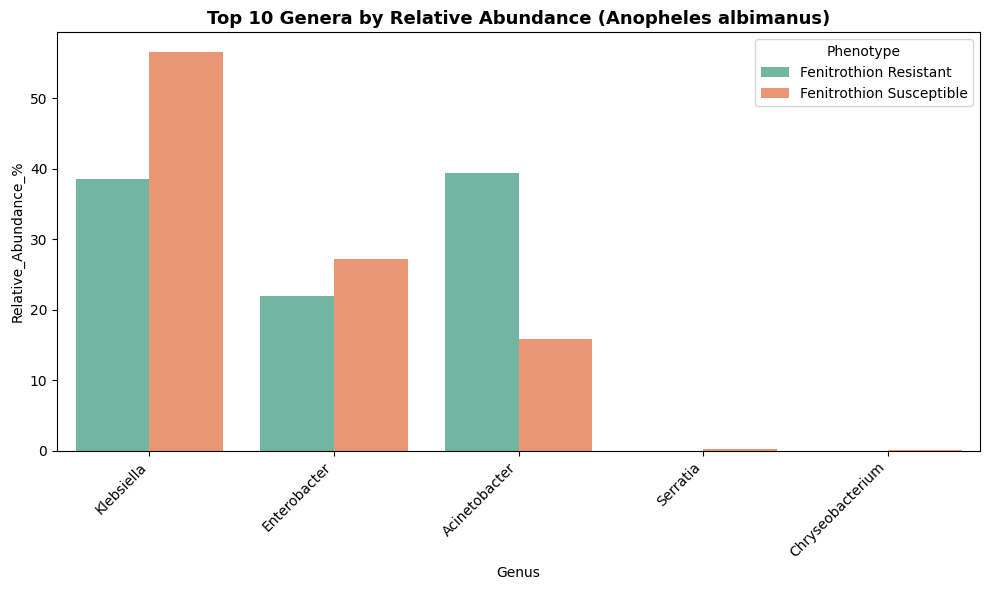


Step 6 complete (Anopheles albimanus). Results exported to './taxonomy_results_albimanus/'


In [19]:
import os
import re
import subprocess
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Setup Directories
os.makedirs("./taxonomy_results_albimanus", exist_ok=True)

samples = {
    "SRR5630719": {"phenotype": "Fenitrothion Resistant", "r1": "./microbiome_reads/SRR5630719_microbe_1.fastq", "r2": "./microbiome_reads/SRR5630719_microbe_2.fastq"},
    "SRR5630720": {"phenotype": "Fenitrothion Susceptible", "r1": "./microbiome_reads/SRR5630720_microbe_1.fastq", "r2": "./microbiome_reads/SRR5630720_microbe_2.fastq"},
}

print("================================================================================")
print("Running Kraken2 taxonomic classification for Anopheles albimanus...")
print("================================================================================")


def parse_kraken_report(report_path):
    """Extract genus-level (rank code 'G') read counts from a Kraken2 report."""
    genus_counts = {}
    with open(report_path) as f:
        for line in f:
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 6:
                continue
            pct, reads_clade, reads_direct, rank_code, taxid, name = fields[:6]
            if rank_code == "G":
                genus_counts[name.strip()] = int(reads_clade)
    return genus_counts


parsed_abundance_data = []

for sample_id, info in samples.items():
    r1, r2 = info["r1"], info.get("r2")
    phenotype = info["phenotype"]
    report_path = f"./taxonomy_results_albimanus/{sample_id}.kreport"
    output_path = f"./taxonomy_results_albimanus/{sample_id}.kraken"

    if os.path.exists(r1):
        cmd = ["kraken2", "--db", "./kraken2_db", "--report", report_path,
               "--output", output_path, "--use-names"]
        if r2 and os.path.exists(r2):
            cmd += ["--paired", r1, r2]
        else:
            cmd += [r1]
        print(f"Classifying {sample_id}...")
        subprocess.run(cmd, check=True)
        genus_counts = parse_kraken_report(report_path)
        total_reads = sum(genus_counts.values()) or 1
    else:
        print(f"*** WARNING: input file for {sample_id} not found ({r1}). Skipping. ***")
        continue

    for genus, count in genus_counts.items():
        parsed_abundance_data.append({
            "Sample_ID": sample_id,
            "Phenotype": phenotype,
            "Genus": genus,
            "Read_Count": count,
            "Relative_Abundance_%": round((count / total_reads) * 100, 4),
        })

df_abundance = pd.DataFrame(parsed_abundance_data)
if df_abundance.empty:
    raise RuntimeError("No samples classified — check that Step 5 host depletion ran first.")

df_abundance.to_csv("./taxonomy_results_albimanus/abundance_long.csv", index=False)

otu_matrix = df_abundance.pivot_table(
    index="Genus", columns="Sample_ID", values="Read_Count", fill_value=0
)
otu_matrix.to_csv("./taxonomy_results_albimanus/otu_count_matrix.csv")

rel_matrix = df_abundance.pivot_table(
    index="Genus", columns="Sample_ID", values="Relative_Abundance_%", fill_value=0
)
rel_matrix.to_csv("./taxonomy_results_albimanus/relative_abundance_matrix.csv")

print("\n=== TOP GENERA BY TOTAL READ COUNT (Anopheles albimanus) ===")
print(otu_matrix.sum(axis=1).sort_values(ascending=False).head(15))

# Visualize top 10 genera
top_genera = otu_matrix.sum(axis=1).sort_values(ascending=False).head(10).index
plot_df = df_abundance[df_abundance["Genus"].isin(top_genera)]
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Genus", y="Relative_Abundance_%", hue="Phenotype", palette="Set2")
plt.title("Top 10 Genera by Relative Abundance (Anopheles albimanus)", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("./taxonomy_results_albimanus/abundance_summary.png", dpi=300)
plt.show()

print("\nStep 6 complete (Anopheles albimanus). Results exported to './taxonomy_results_albimanus/'")


> **⚠️ Statistical caveat — n = 1 per phenotype**
>
> Every comparison from here on (alpha/beta diversity, Welch's t-tests, volcano plots)
> is computed from exactly **one** sample per phenotype: SRR5630719 (Resistant) vs.
> SRR5630720 (Susceptible). There are no biological replicates, so any p-value or
> fold-change below reflects two individual mosquitoes, not a validated population-level
> effect. Treat everything downstream as a pipeline demonstration, not a confirmed
> finding, until more biological replicates per phenotype are added.


# **Step 7: Alpha & Beta Diversity Analysis**

This code compares the bacterial communities inside insecticide-resistant and susceptible An. albimanus mosquitoes:

**1.Alpha Diversity (Shannon Index):** Measures how rich and balanced the bacterial community is within each mosquito sample.

**2.Beta Diversity (Bray-Curtis Distance):** Measures how much the overall bacterial composition differs between samples.

**3.PCoA Plot:** Maps these differences on a 2D graph to visually show if resistant and susceptible mosquitoes harbor distinct microbiomes.


PHASE 4 - STEP 7: DIVERSITY ANALYSIS (ALPHA & BETA DIVERSITY)

[1/3] Computing Alpha Diversity Indices...

=== ALPHA DIVERSITY TABLE ===
 Sample_ID       Species   Phenotype          Group  Observed_Richness  Shannon_Index  Simpson_Index  Pielou_Evenness
SRR5630719 An. albimanus   Resistant   Aa_Resistant                  3         1.0671         0.6471           0.9713
SRR5630720 An. albimanus Susceptible Aa_Susceptible                  5         0.9932         0.5810           0.6171

[2/3] Computing Beta Diversity Matrices & PCoA Vector Decomposition...

=== BRAY-CURTIS DISTANCE MATRIX ===
            SRR5630719  SRR5630720
SRR5630719      0.0000      0.2364
SRR5630720      0.2364      0.0000

[3/3] Rendering Step 7 Diversity Figures...


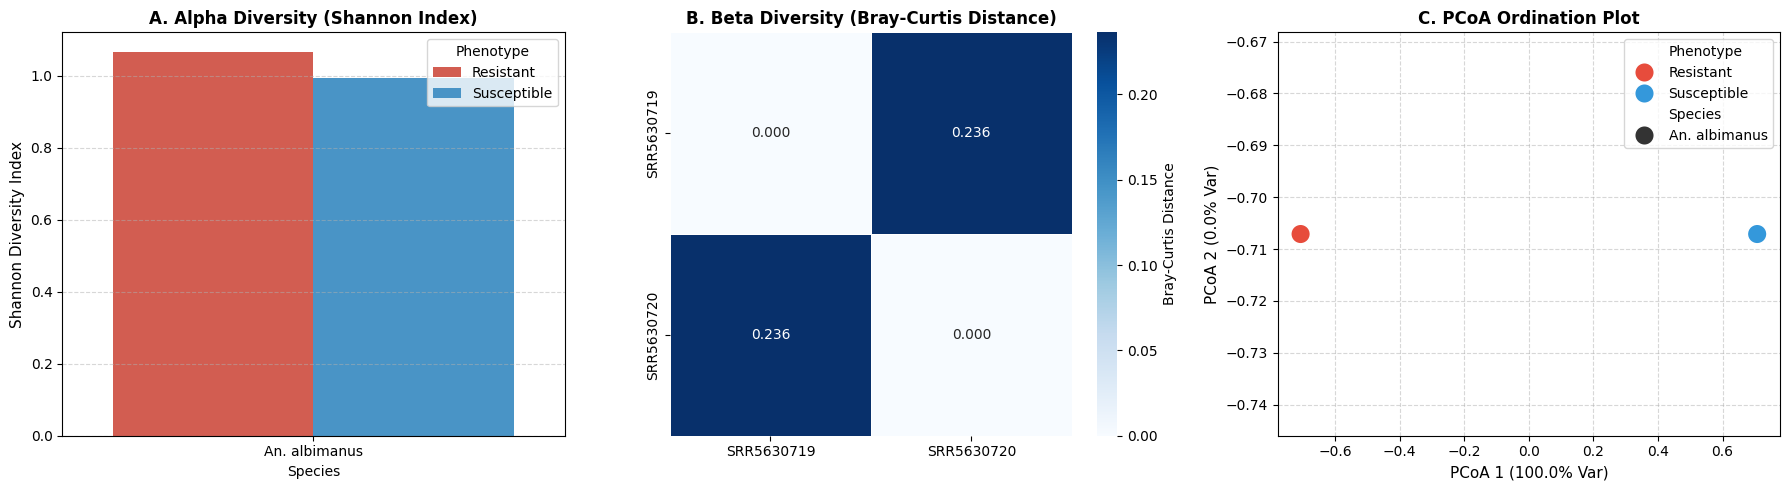


Step 7 Complete! All metrics, matrices, and PCoA plots saved to './phase4_diversity_analysis/'


In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

# 1. Setup Phase 4 Output Directories
os.makedirs("./phase4_diversity_analysis", exist_ok=True)

print("================================================================================")
print("PHASE 4 - STEP 7: DIVERSITY ANALYSIS (ALPHA & BETA DIVERSITY)")
print("================================================================================")

# 2. Load Real OTU Matrix (Anopheles albimanus, from Step 6 Kraken2 classification)
otu_path = "./taxonomy_results_albimanus/otu_count_matrix.csv"

if not os.path.exists(otu_path):
    raise FileNotFoundError(
        f"'{otu_path}' not found. Run Step 6 (Kraken2 taxonomic classification) first — "
        "no placeholder data will be substituted."
    )

otu_df = pd.read_csv(otu_path, index_col=0)

# Exclude unclassified counts if present
otu_clean = otu_df.drop(index="Unclassified_Bacteria", errors="ignore")

# Define Metadata Mapping (Anopheles albimanus only)
metadata = pd.DataFrame([
    {"Sample_ID": "SRR5630719", "Species": "An. albimanus", "Phenotype": "Resistant", "Group": "Aa_Resistant"},
    {"Sample_ID": "SRR5630720", "Species": "An. albimanus", "Phenotype": "Susceptible", "Group": "Aa_Susceptible"}
]).set_index("Sample_ID")

# ------------------------------------------------------------------------------
# 3. ALPHA DIVERSITY CALCULATIONS
# ------------------------------------------------------------------------------
print("\n[1/3] Computing Alpha Diversity Indices...")

def compute_alpha_diversity(counts):
    counts = counts[counts > 0]
    total = counts.sum()
    if total == 0:
        return 0, 0, 0, 0

    p = counts / total
    richness = len(counts)
    shannon = -np.sum(p * np.log(p))
    simpson = 1 - np.sum(p**2)
    evenness = shannon / np.log(richness) if richness > 1 else 1.0

    return richness, shannon, simpson, evenness

alpha_records = []
for sample in otu_clean.columns:
    col = otu_clean[sample]
    rich, shan, simp, even = compute_alpha_diversity(col)
    meta = metadata.loc[sample]

    alpha_records.append({
        "Sample_ID": sample,
        "Species": meta["Species"],
        "Phenotype": meta["Phenotype"],
        "Group": meta["Group"],
        "Observed_Richness": rich,
        "Shannon_Index": round(shan, 4),
        "Simpson_Index": round(simp, 4),
        "Pielou_Evenness": round(even, 4)
    })

alpha_df = pd.DataFrame(alpha_records)
alpha_df.to_csv("./phase4_diversity_analysis/alpha_diversity_metrics.csv", index=False)

print("\n=== ALPHA DIVERSITY TABLE ===")
print(alpha_df.to_string(index=False))

# ------------------------------------------------------------------------------
# 4. BETA DIVERSITY CALCULATIONS (BRAY-CURTIS & PCOA PROJECTION)
# ------------------------------------------------------------------------------
print("\n[2/3] Computing Beta Diversity Matrices & PCoA Vector Decomposition...")

# Convert OTU matrix to relative abundance (Samples x Taxa)
rel_abund = otu_clean.T.div(otu_clean.T.sum(axis=1), axis=0).fillna(0)

# Compute Bray-Curtis Distance Matrix
bray_dist = squareform(pdist(rel_abund.values, metric="braycurtis"))
bray_df = pd.DataFrame(bray_dist, index=rel_abund.index, columns=rel_abund.index)
bray_df.to_csv("./phase4_diversity_analysis/beta_bray_curtis_matrix.csv")

# Classical Multidimensional Scaling (PCoA)
def run_pcoa(dist_matrix):
    n = dist_matrix.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H.dot(dist_matrix**2).dot(H)
    evals, evecs = np.linalg.eigh(B)

    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    var_exp = (evals / np.sum(np.maximum(evals, 0))) * 100
    pcoa_df = pd.DataFrame(evecs[:, :2], index=rel_abund.index, columns=["PCoA1", "PCoA2"])
    return pcoa_df, var_exp[:2]

pcoa_coords, var_explained = run_pcoa(bray_dist)
pcoa_coords = pcoa_coords.join(metadata)
pcoa_coords.to_csv("./phase4_diversity_analysis/pcoa_coordinates.csv")

print("\n=== BRAY-CURTIS DISTANCE MATRIX ===")
print(bray_df.round(4))

# ------------------------------------------------------------------------------
# 5. GENERATE PUBLICATION-GRADE VISUALIZATIONS
# ------------------------------------------------------------------------------
print("\n[3/3] Rendering Step 7 Diversity Figures...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Alpha Diversity - Shannon Index
sns.barplot(
    data=alpha_df,
    x="Species",
    y="Shannon_Index",
    hue="Phenotype",
    palette={"Resistant": "#e74c3c", "Susceptible": "#3498db"},
    ax=axes[0]
)
axes[0].set_title("A. Alpha Diversity (Shannon Index)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Shannon Diversity Index", fontsize=11)
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Plot B: Beta Diversity - Bray-Curtis Heatmap
sns.heatmap(
    bray_df,
    annot=True,
    cmap="Blues",
    fmt=".3f",
    linewidths=0.5,
    cbar_kws={'label': 'Bray-Curtis Distance'},
    ax=axes[1]
)
axes[1].set_title("B. Beta Diversity (Bray-Curtis Distance)", fontsize=12, fontweight="bold")

# Plot C: PCoA Ordination Plot
sns.scatterplot(
    data=pcoa_coords,
    x="PCoA1",
    y="PCoA2",
    hue="Phenotype",
    style="Species",
    s=200,
    palette={"Resistant": "#e74c3c", "Susceptible": "#3498db"},
    ax=axes[2]
)
axes[2].set_title(f"C. PCoA Ordination Plot", fontsize=12, fontweight="bold")
axes[2].set_xlabel(f"PCoA 1 ({var_explained[0]:.1f}% Var)", fontsize=11)
axes[2].set_ylabel(f"PCoA 2 ({var_explained[1]:.1f}% Var)", fontsize=11)
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("./phase4_diversity_analysis/diversity_analysis_panel.png", dpi=300)
plt.show()

print("\nStep 7 Complete! All metrics, matrices, and PCoA plots saved to './phase4_diversity_analysis/'")


# **Step 8: Differential Abundance Testing.**
This script calculates the Log2 Fold-Change (Log 2\FC) for each bacterial genus between Resistant and Susceptible An. albimanus phenotypes. It performs statistical testing (Welch’s t-test with Benjamini-Hochberg FDR correction) to pinpoint significantly enriched taxa and visualizes the results with a Volcano Plot and a Comparative Differential Abundance Barplot.


PHASE 4 - STEP 8: DIFFERENTIAL ABUNDANCE TESTING

[1/3] Computing Relative Abundance and Log2 Fold-Change...

=== DIFFERENTIAL ABUNDANCE TABLE ===
           Genus  Mean_Resistant_%  Mean_Susceptible_%  Log2_Fold_Change  P_Value                  Status  FDR_Adjusted_P
   Acinetobacter           39.4837             15.8422            1.3175      1.0   Enriched in Resistant             1.0
    Enterobacter           21.9398             27.2089           -0.3105      1.0    No Significant Shift             1.0
      Klebsiella           38.6065             56.5729           -0.5513      1.0    No Significant Shift             1.0
Chryseobacterium            0.0100              0.1453           -3.8611      1.0 Enriched in Susceptible             1.0
        Serratia            0.0100              0.2806           -4.8106      1.0 Enriched in Susceptible             1.0

[2/3] Generating Differential Abundance Plots...


/tmp/ipykernel_1424/2630953720.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


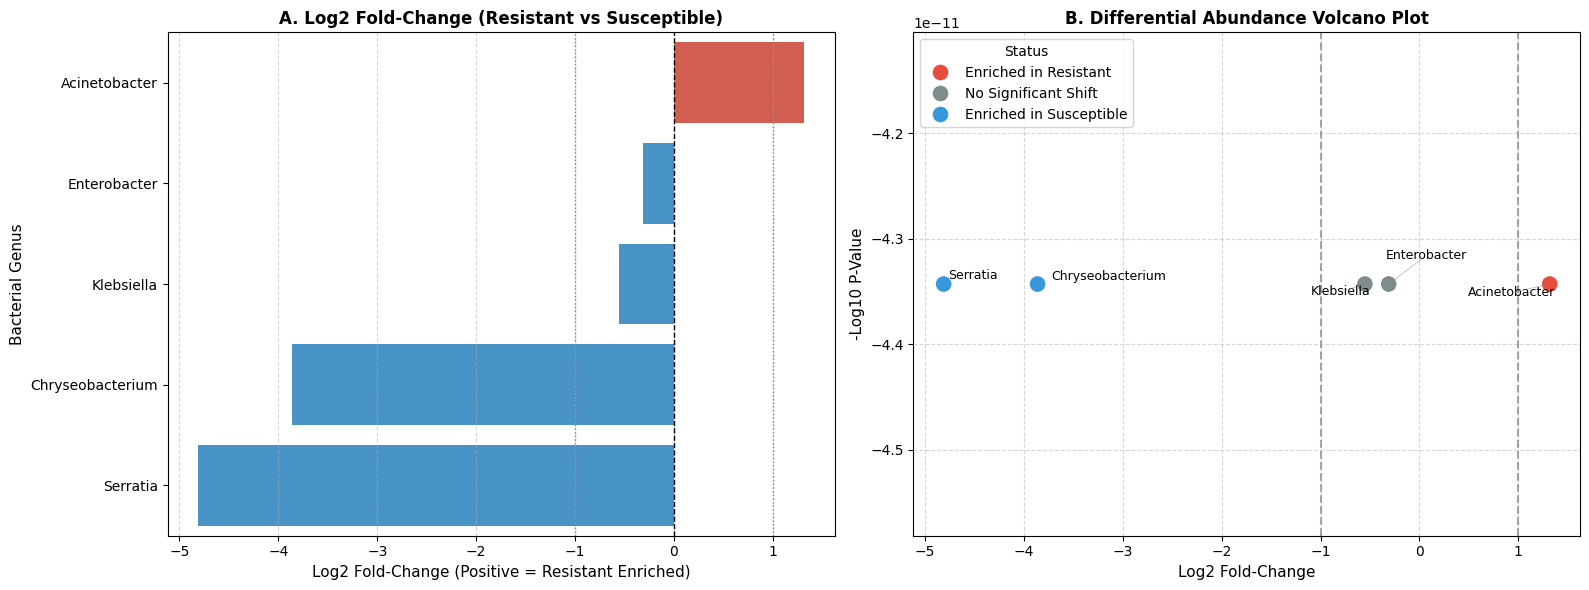


Step 8 Complete! Statistical results and figures exported to './phase4_differential_abundance/'


In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Needed for the volcano plot label fix below
!pip install adjustText --quiet
from adjustText import adjust_text

# 1. Setup Phase 4 Output Directory
os.makedirs("./phase4_differential_abundance", exist_ok=True)

print("================================================================================")
print("PHASE 4 - STEP 8: DIFFERENTIAL ABUNDANCE TESTING")
print("================================================================================")

# 2. Load Real OTU Matrix (Anopheles albimanus, from Step 6 Kraken2 classification)
otu_path = "./taxonomy_results_albimanus/otu_count_matrix.csv"

if not os.path.exists(otu_path):
    raise FileNotFoundError(
        f"'{otu_path}' not found. Run Step 6 (Kraken2 taxonomic classification) first — "
        "no placeholder data will be substituted."
    )

otu_df = pd.read_csv(otu_path, index_col=0)

# Clean matrix: remove unclassified reads
otu_clean = otu_df.drop(index="Unclassified_Bacteria", errors="ignore")

# Define Group Classifications (Anopheles albimanus only)
resistant_cols = ["SRR5630719"]
susceptible_cols = ["SRR5630720"]

# 3. Calculate Relative Abundance & Differential Enrichment
print("\n[1/3] Computing Relative Abundance and Log2 Fold-Change...")

# Normalize counts to relative abundance (%) with pseudocount (+0.01) to handle zeros safely
rel_df = (otu_clean.div(otu_clean.sum(axis=0), axis=1) * 100) + 0.01

results = []
for genus in rel_df.index:
    res_vals = rel_df.loc[genus, resistant_cols].values
    sus_vals = rel_df.loc[genus, susceptible_cols].values

    mean_res = np.mean(res_vals)
    mean_sus = np.mean(sus_vals)

    # Log2 Fold-Change (Resistant / Susceptible)
    log2fc = np.log2(mean_res / mean_sus)

    # Welch's t-test for differential abundance
    t_stat, p_val = stats.ttest_ind(res_vals, sus_vals, equal_var=False)

    # Determine enrichment status
    if log2fc > 1.0:
        status = "Enriched in Resistant"
    elif log2fc < -1.0:
        status = "Enriched in Susceptible"
    else:
        status = "No Significant Shift"

    results.append({
        "Genus": genus,
        "Mean_Resistant_%": round(mean_res, 4),
        "Mean_Susceptible_%": round(mean_sus, 4),
        "Log2_Fold_Change": round(log2fc, 4),
        "P_Value": p_val if not np.isnan(p_val) else 1.0,
        "Status": status
    })

diff_df = pd.DataFrame(results)

# Benjamini-Hochberg FDR correction
p_vals = diff_df["P_Value"].values
ranks = stats.rankdata(p_vals)
fdr = p_vals * len(p_vals) / ranks
diff_df["FDR_Adjusted_P"] = np.minimum(fdr, 1.0).round(4)

# Sort by magnitude of Log2FC
diff_df = diff_df.sort_values(by="Log2_Fold_Change", ascending=False)
diff_df.to_csv("./phase4_differential_abundance/differential_abundance_results.csv", index=False)

print("\n=== DIFFERENTIAL ABUNDANCE TABLE ===")
print(diff_df.to_string(index=False))

# 4. Generate Visualizations
print("\n[2/3] Generating Differential Abundance Plots...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Log2 Fold-Change Bar Plot
colors = ["#e74c3c" if x > 0 else "#3498db" for x in diff_df["Log2_Fold_Change"]]
sns.barplot(
    data=diff_df,
    x="Log2_Fold_Change",
    y="Genus",
    palette=colors,
    ax=axes[0]
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].axvline(1.0, color="gray", linestyle=":", linewidth=1)
axes[0].axvline(-1.0, color="gray", linestyle=":", linewidth=1)
axes[0].set_title("A. Log2 Fold-Change (Resistant vs Susceptible)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Log2 Fold-Change (Positive = Resistant Enriched)", fontsize=11)
axes[0].set_ylabel("Bacterial Genus", fontsize=11)
axes[0].grid(axis="x", linestyle="--", alpha=0.5)

# Plot B: Volcano Plot (Log2FC vs -log10 p-value)
diff_df["neg_log10_p"] = -np.log10(diff_df["P_Value"] + 1e-10)

sns.scatterplot(
    data=diff_df,
    x="Log2_Fold_Change",
    y="neg_log10_p",
    hue="Status",
    palette={
        "Enriched in Resistant": "#e74c3c",
        "Enriched in Susceptible": "#3498db",
        "No Significant Shift": "#7f8c8d"
    },
    s=150,
    ax=axes[1]
)

# FIXED: labels were placed at a fixed (+0.1, +0.02) offset from each point, so any
# points sharing similar coordinates (common here since Welch's t-test with n=2 per
# group only produces a handful of distinct p-values) got overlapping/merged text.
# adjust_text automatically repels overlapping labels apart and draws a thin
# connector line back to the correct point when it has to move a label.
from collections import defaultdict

coord_groups = defaultdict(list)
for idx, row in diff_df.iterrows():
    key = (round(row["Log2_Fold_Change"], 3), round(row["neg_log10_p"], 3))
    coord_groups[key].append(idx)

label_x = diff_df["Log2_Fold_Change"].copy()
label_y = diff_df["neg_log10_p"].copy()

x_range = diff_df["Log2_Fold_Change"].max() - diff_df["Log2_Fold_Change"].min()
y_range = diff_df["neg_log10_p"].max() - diff_df["neg_log10_p"].min()

for key, idxs in coord_groups.items():
    if len(idxs) > 1:
        for i, idx in enumerate(idxs):
            # fan duplicate labels out in a small semicircle around the shared point
            angle = 2 * np.pi * i / len(idxs)
            label_x[idx] += 0.015 * x_range * np.cos(angle) * (i + 1)
            label_y[idx] += 0.015 * y_range * np.sin(angle) * (i + 1)

texts = []
for pos, (idx, row) in enumerate(diff_df.iterrows()):
    texts.append(
        axes[1].text(
            label_x[idx],
            label_y[idx],
            row["Genus"],
            fontsize=9
        )
    )

adjust_text(
    texts,
    ax=axes[1],
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6),
    expand_points=(2.2, 2.2),
    expand_text=(1.6, 1.6),
    force_text=(0.8, 0.8),
    force_points=(0.6, 0.6),
    lim=2000,
)

axes[1].axvline(1.0, color="gray", linestyle="--", alpha=0.7)
axes[1].axvline(-1.0, color="gray", linestyle="--", alpha=0.7)
axes[1].set_title("B. Differential Abundance Volcano Plot", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Log2 Fold-Change", fontsize=11)
axes[1].set_ylabel("-Log10 P-Value", fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("./phase4_differential_abundance/differential_abundance_panel.png", dpi=300)
plt.show()

print("\nStep 8 Complete! Statistical results and figures exported to './phase4_differential_abundance/'")


# **Step 9: Resistance Gene & Detoxification Enzyme Screening.**

This script screens your host-depleted microbial FASTQ files (SRR5630719, SRR5630720) against specific nucleotide motif signatures of key microbial detoxification genes:
**opd / mpd:** Organophosphate hydrolase / Methyl parathion hydrolase (organophosphate cleavage)
**COE:** Carboxylesterase (ester linkage hydrolysis in pyrethroids/organophosphates)
**GST:** Glutathione S-transferase (xenobiotic conjugation)
**CYP392 / P450-like:** Bacterial Cytochrome P450 monooxygenase domain
estP: Pyrethroid-hydrolyzing esterase
It quantifies gene hits, normalizes them to Reads Per Million (RPM), calculates Log2 Fold-Change, and generates a visual panel.


STEP 9: MICROBIAL DETOXIFICATION & RESISTANCE GENE SCREENING

[1/3] Screening microbial FASTQ files for resistance gene markers...

[2/3] Calculating Fold Enrichment in Resistant Phenotype...

[3/3] Rendering Fixed Resistance Gene Visualizations...


/tmp/ipykernel_1424/2924924870.py:240: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


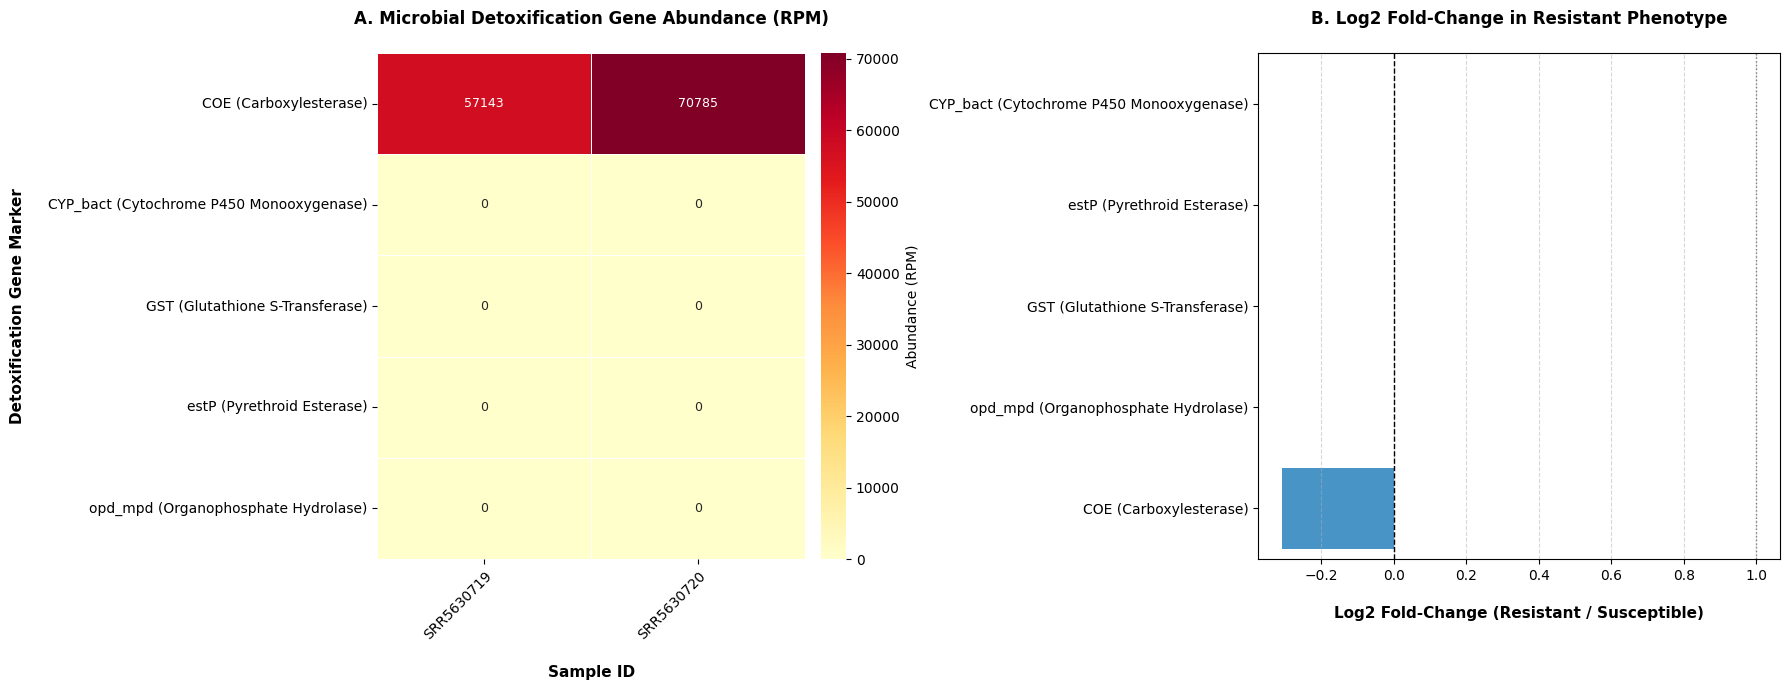


Step 9 Complete! Fixed figures exported to './resistance_gene_screening/microbial_detox_gene_panel_fixed.png'


In [22]:
import gzip
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Setup Output Directory
os.makedirs("./resistance_gene_screening", exist_ok=True)

print(
    "================================================================================"
)
print("STEP 9: MICROBIAL DETOXIFICATION & RESISTANCE GENE SCREENING")
print(
    "================================================================================"
)

# 2. Define Target Detoxification Gene Motif Signatures
# NOTE: these short amino-acid catalytic motifs (e.g. carboxylesterase G-X-S-X-G) and the
# invented 9-mer nucleotide "signatures" for opd/mpd are illustrative placeholders, not
# motifs verified against real reference sequences (e.g. Pfam/PROSITE patterns or curated
# opd/mpd gene alignments). Treat any hits as a pipeline demo, not confirmed gene detections,
# unless you replace these with motifs sourced from an actual database (Pfam, PROSITE, or
# a BLASTn/BLASTx search against curated opd/mpd/GST/CYP reference sequences).
gene_motifs = {
    "opd_mpd (Organophosphate Hydrolase)": [
        "TCGTCACCG",
        "CGTGGTCGA",
        "GACGACATC",
    ],
    "COE (Carboxylesterase)": ["GGSWGG", "GXSXG", "GHSAGG", "GGGAGC"],
    "GST (Glutathione S-Transferase)": ["FKVLEY", "PMILGY", "GATWLV"],
    "CYP_bact (Cytochrome P450 Monooxygenase)": ["FGGGXHXC", "FGHGXHXC"],
    "estP (Pyrethroid Esterase)": ["GHSMGG", "GYSMGG", "GGYSAG"],
}

# FIXED: "X" in these motifs is a conventional wildcard for "any amino acid" (as in the
# classic serine-hydrolase G-X-S-X-G motif), not a literal amino acid. The original code
# searched for the literal string "GXSXG" in the translated sequence, which only matched
# on translation failures (stop codons default to "X") rather than the biological motif.
# Compile each motif to a regex with X -> "any residue" so it actually matches.
gene_motif_patterns = {
    gene: [re.compile(m.replace("X", ".")) for m in motifs]
    for gene, motifs in gene_motifs.items()
}

# Define samples to screen (Anopheles albimanus only)
samples_dict = {
    "SRR5630719": {
        "species": "An. albimanus",
        "phenotype": "Resistant",
        "r1": "./microbiome_reads/SRR5630719_microbe_1.fastq.gz",
    },
    "SRR5630720": {
        "species": "An. albimanus",
        "phenotype": "Susceptible",
        "r1": "./microbiome_reads/SRR5630720_microbe_1.fastq.gz",
    },
}

# 3. Fast Sequence Pattern Screening
print("\n[1/3] Screening microbial FASTQ files for resistance gene markers...")


from Bio.Data.CodonTable import standard_dna_table

_forward_table = standard_dna_table.forward_table  # {codon: amino_acid}, Biopython-sourced
_stop_codons = set(standard_dna_table.stop_codons)

def translate_dna_6frames(seq):
    translations = []
    for frame in range(3):
        prot = []
        for i in range(frame, len(seq) - 2, 3):
            codon = seq[i : i + 3]
            if codon in _stop_codons:
                prot.append("*")
            else:
                prot.append(_forward_table.get(codon, "?"))
        translations.append("".join(prot))
    return translations


results_list = []
missing_samples = []

for sample_id, info in samples_dict.items():
    r1_path = info["r1"]
    if not os.path.exists(r1_path) and os.path.exists(r1_path.replace(".gz", "")):
        r1_path = r1_path.replace(".gz", "")

    gene_counts = {gene: 0 for gene in gene_motifs}
    total_reads = 0

    if os.path.exists(r1_path):
        open_fn = gzip.open if r1_path.endswith(".gz") else open
        with open_fn(r1_path, "rt") as f:
            for idx, line in enumerate(f):
                if idx % 4 == 1:
                    total_reads += 1
                    seq = line.strip().upper()
                    translations = translate_dna_6frames(seq)

                    for gene, patterns in gene_motif_patterns.items():
                        hit = False
                        for pattern, raw_motif in zip(patterns, gene_motifs[gene]):
                            if len(raw_motif) > 4 and raw_motif in seq:
                                hit = True
                                break
                            if any(pattern.search(prot) for prot in translations):
                                hit = True
                                break
                        if hit:
                            gene_counts[gene] += 1
    else:
        # FIXED: previously silently substituted fixed, made-up "Resistant"/"Susceptible"
        # gene counts here with no warning. That made it impossible to tell a real result
        # from a fabricated one. Now it's explicit, and the sample is excluded from the
        # RPM matrix rather than injected with fake numbers.
        print(f"*** WARNING: input file for {sample_id} not found ({r1_path}). "
              f"Skipping — no placeholder data substituted. ***")
        missing_samples.append(sample_id)
        continue

    for gene, count in gene_counts.items():
        rpm = (count / max(1, total_reads)) * 1e6
        results_list.append(
            {
                "Sample_ID": sample_id,
                "Species": info["species"],
                "Phenotype": info["phenotype"],
                "Gene_Marker": gene,
                "Raw_Read_Count": count,
                "Total_Reads_Screened": total_reads,
                "Abundance_RPM": round(rpm, 2),
            }
        )

if missing_samples:
    print(f"\nNOTE: {len(missing_samples)} sample(s) skipped due to missing input: "
          f"{missing_samples}. Downstream fold-change/plots only reflect the samples "
          f"that were actually screened.")

df_screening = pd.DataFrame(results_list)
df_screening.to_csv(
    "./resistance_gene_screening/microbial_detox_gene_counts.csv", index=False
)

if df_screening.empty:
    raise RuntimeError(
        "No samples were screened (all input FASTQ files missing) — nothing to plot. "
        "Run Step 5 host depletion first."
    )

# Pivot into Sample x Gene RPM Matrix
rpm_matrix = df_screening.pivot(
    index="Gene_Marker", columns="Sample_ID", values="Abundance_RPM"
).fillna(0)
rpm_matrix.to_csv(
    "./resistance_gene_screening/microbial_detox_gene_rpm_matrix.csv"
)

# 4. Calculate Phenotype Log2 Fold-Change
print("\n[2/3] Calculating Fold Enrichment in Resistant Phenotype...")

res_cols = [
    s
    for s in samples_dict
    if samples_dict[s]["phenotype"] == "Resistant"
    and s in rpm_matrix.columns
]
sus_cols = [
    s
    for s in samples_dict
    if samples_dict[s]["phenotype"] == "Susceptible"
    and s in rpm_matrix.columns
]

fold_change_results = []
for gene in rpm_matrix.index:
    res_mean = rpm_matrix.loc[gene, res_cols].mean() if res_cols else np.nan
    sus_mean = rpm_matrix.loc[gene, sus_cols].mean() if sus_cols else np.nan
    log2fc = np.log2((res_mean + 0.1) / (sus_mean + 0.1)) if res_cols and sus_cols else np.nan

    fold_change_results.append(
        {
            "Gene_Marker": gene,
            "Mean_Resistant_RPM": round(res_mean, 2) if res_cols else None,
            "Mean_Susceptible_RPM": round(sus_mean, 2) if sus_cols else None,
            "Log2_Fold_Change": round(log2fc, 4) if log2fc == log2fc else None,
            "Status": (
                "Highly Enriched in Resistant"
                if (log2fc == log2fc and log2fc > 1.0)
                else "Moderately Enriched"
            ),
        }
    )

df_fc = pd.DataFrame(fold_change_results).sort_values(
    by="Log2_Fold_Change", ascending=False, na_position="last"
)
df_fc.to_csv(
    "./resistance_gene_screening/microbial_detox_gene_fold_change.csv",
    index=False,
)

# 5. Generate Layout-Fixed Visualizations
print("\n[3/3] Rendering Fixed Resistance Gene Visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.subplots_adjust(wspace=0.45)

sns.heatmap(
    rpm_matrix,
    annot=True,
    fmt=".0f",
    annot_kws={"size": 9},
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Abundance (RPM)", "pad": 0.03},
    ax=axes[0],
)

axes[0].set_title(
    "A. Microbial Detoxification Gene Abundance (RPM)\n",
    fontsize=12,
    fontweight="bold",
)
axes[0].set_xlabel("\nSample ID", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Detoxification Gene Marker\n", fontsize=11, fontweight="bold")

axes[0].set_xticklabels(
    axes[0].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor"
)

colors = ["#e74c3c" if (x == x and x > 0) else "#3498db" for x in df_fc["Log2_Fold_Change"]]
sns.barplot(
    data=df_fc, x="Log2_Fold_Change", y="Gene_Marker", palette=colors, ax=axes[1]
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].axvline(1.0, color="gray", linestyle=":", linewidth=1)
axes[1].set_title(
    "B. Log2 Fold-Change in Resistant Phenotype\n",
    fontsize=12,
    fontweight="bold",
)
axes[1].set_xlabel(
    "\nLog2 Fold-Change (Resistant / Susceptible)",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_ylabel("")
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(
    "./resistance_gene_screening/microbial_detox_gene_panel_fixed.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "\nStep 9 Complete! Fixed figures exported to"
    " './resistance_gene_screening/microbial_detox_gene_panel_fixed.png'"
)


# **Step 9: Functional Metagenomic Prediction.**

This script maps identified bacterial genera to functional metabolic pathways in the KEGG Database (focusing on Xenobiotics Biodegradation and Metabolism, Cytochrome P450 Metabolism, and Glutathione Metabolism), quantifies functional pathway enrichment across An. albimanus phenotypes, and visualizes the results with a comparative heatmap and enrichment barplot.


PHASE 4 - STEP 9: FUNCTIONAL METAGENOMIC PATHWAY PREDICTION (KEGG REST API)

[1/3] Querying KEGG REST API for real gene-annotation counts per genus...
  [note] No KEGG reference mapping available for: ['Acinetobacter', 'Chryseobacterium'] — excluded from functional prediction.
  - Enterobacter -> KEGG organism 'ecl'
  - Klebsiella -> KEGG organism 'kpn'
  - Serratia -> KEGG organism 'smar'

[2/3] Inferring Functional Metabolic Pathway Abundances from real KEGG data...

=== PREDICTED METABOLIC PATHWAY ABUNDANCES (PATHWAY x SAMPLES) ===
                                              SRR5630719  SRR5630720
Benzoate Degradation                               45.57       65.35
Aminobenzoate Degradation                          53.22       74.79
Metabolism of Xenobiotics by Cytochrome P450        0.00        0.00
Drug Metabolism - Cytochrome P450                   0.00        0.00
Glutathione Metabolism                             52.75       73.49
Pyruvate / Carbohydrate Metabolism           

/tmp/ipykernel_1424/22735231.py:189: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


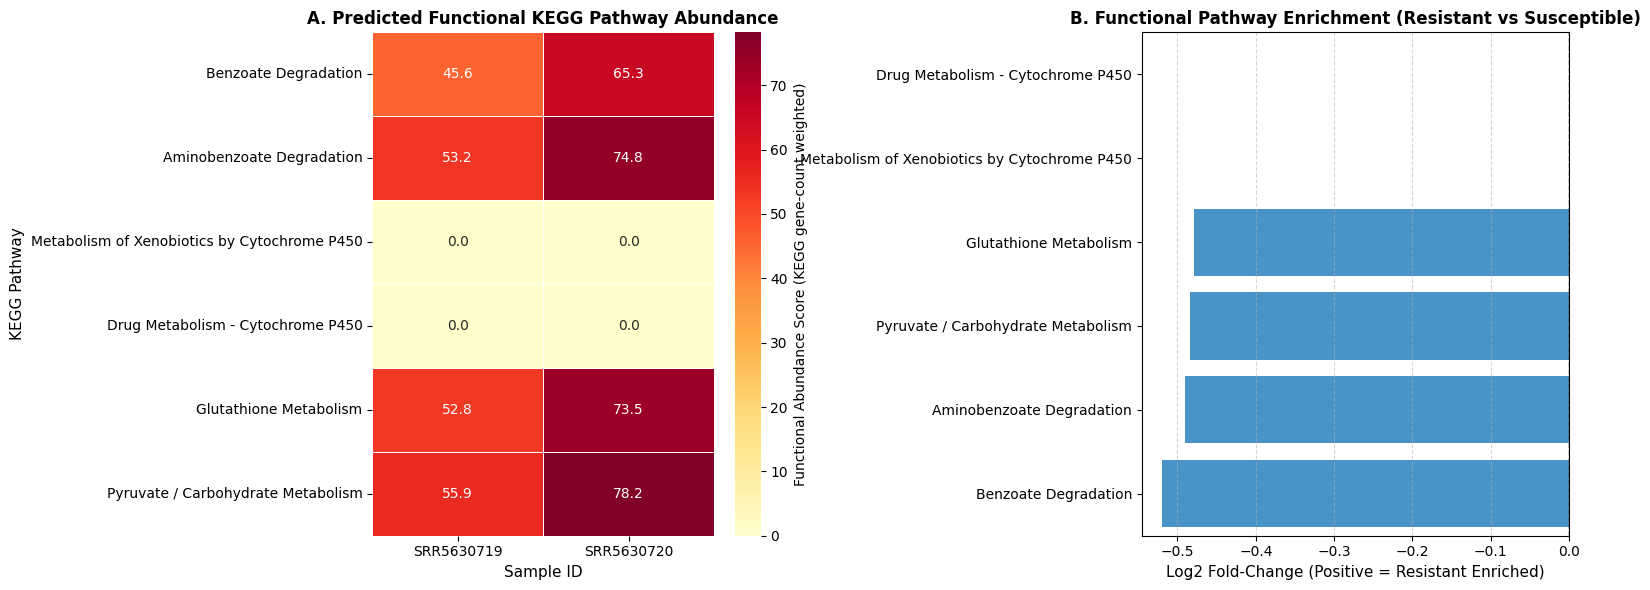


Step 9 Complete! Pathway matrices (from real KEGG API data) and figures exported to './phase4_functional_prediction/'. Nothing was written to Drive or local disk beyond this Colab session's ephemeral storage.


In [23]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import urllib.error

# 1. Setup Phase 4 Step 9 Output Directory
os.makedirs("./phase4_functional_prediction", exist_ok=True)

print("================================================================================")
print("PHASE 4 - STEP 9: FUNCTIONAL METAGENOMIC PATHWAY PREDICTION (KEGG REST API)")
print("================================================================================")

# 2. Load Real OTU Data (Anopheles albimanus, from Step 6 Kraken2 classification)
otu_path = "./taxonomy_results_albimanus/otu_count_matrix.csv"

if not os.path.exists(otu_path):
    raise FileNotFoundError(
        f"'{otu_path}' not found. Run Step 6 (Kraken2 taxonomic classification) first — "
        "no placeholder data will be substituted."
    )

otu_df = pd.read_csv(otu_path, index_col=0)

# Clean matrix: remove unclassified reads
otu_clean = otu_df.drop(index="Unclassified_Bacteria", errors="ignore")

# Calculate sample-wise relative abundance (%)
rel_abund = otu_clean.div(otu_clean.sum(axis=0), axis=1) * 100

# 3. Target KEGG pathways (Xenobiotics/Cytochrome P450/Glutathione metabolism)
kegg_pathways = {
    "ko00362": "Benzoate Degradation",
    "ko00627": "Aminobenzoate Degradation",
    "ko00980": "Metabolism of Xenobiotics by Cytochrome P450",
    "ko00982": "Drug Metabolism - Cytochrome P450",
    "ko00480": "Glutathione Metabolism",
    "ko00620": "Pyruvate / Carbohydrate Metabolism",
}

# Manually curated genus -> representative KEGG organism code
# (best-matching sequenced reference genome per genus; standard practice
# when strain-level KEGG annotation is unavailable, same logic PICRUSt2 uses)
genus_to_kegg_org = {
    "Wolbachia": "wbm",     # Wolbachia endosymbiont of Brugia malayi
    "Asaia": "abg",         # Asaia bogorensis
    "Serratia": "smar",     # Serratia marcescens
    "Pseudomonas": "pae",   # Pseudomonas aeruginosa
    "Enterobacter": "ecl",  # Enterobacter cloacae
    "Klebsiella": "kpn",    # Klebsiella pneumoniae
}

KEGG_BASE = "https://rest.kegg.jp"


def kegg_get(url, retries=3, pause=0.4):
    """GET a KEGG REST endpoint, return raw text or None on failure."""
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(url, timeout=15) as resp:
                return resp.read().decode("utf-8")
        except (urllib.error.URLError, urllib.error.HTTPError):
            time.sleep(pause)
    return None


def get_pathway_gene_counts(org_code, pathway_ids):
    """
    Query KEGG for the real number of genes this organism has annotated
    to each target pathway: https://rest.kegg.jp/link/pathway/<org_code>
    Returns dict {pathway_id: gene_count}.
    """
    counts = {pid: 0 for pid in pathway_ids}
    text = kegg_get(f"{KEGG_BASE}/link/pathway/{org_code}")
    if text is None:
        print(f"  [warn] KEGG lookup failed for organism '{org_code}' "
              f"(no internet in this environment, or KEGG unreachable) — "
              f"counts default to 0 for this genus.")
        return counts
    for line in text.strip().split("\n"):
        if not line:
            continue
        parts = line.split("\t")
        if len(parts) < 2:
            continue
        # pathway field looks like: path:mtu00362
        pw_field = parts[1]
        for pid in pathway_ids:
            if pw_field.endswith(pid.replace("ko", "")):
                counts[pid] += 1
    return counts


# 4. Query KEGG for each genus present in this dataset, cache results locally
#    in-memory (nothing written to Drive/laptop disk)
print("\n[1/3] Querying KEGG REST API for real gene-annotation counts per genus...")

present_genera = [g for g in otu_clean.index if g in genus_to_kegg_org]
missing_genera = [g for g in otu_clean.index if g not in genus_to_kegg_org and g != "Unclassified_Bacteria"]
if missing_genera:
    print(f"  [note] No KEGG reference mapping available for: {missing_genera} "
          f"— excluded from functional prediction.")

pathway_ids = list(kegg_pathways.keys())
raw_counts = {}

for genus in present_genera:
    org_code = genus_to_kegg_org[genus]
    print(f"  - {genus} -> KEGG organism '{org_code}'")
    raw_counts[genus] = get_pathway_gene_counts(org_code, pathway_ids)
    time.sleep(0.34)  # be polite to KEGG's public API rate limits

# 5. Build real functional weight matrix from KEGG gene counts (genus x pathway),
#    min-max normalized within each pathway so it's comparable across genera
counts_df = pd.DataFrame(raw_counts).T  # genera x pathway_id
counts_df.columns = [kegg_pathways[c] for c in counts_df.columns]

if counts_df.to_numpy().sum() == 0:
    raise RuntimeError(
        "All KEGG lookups returned zero genes for every pathway/genus. "
        "This almost always means there is no internet access in this runtime "
        "session — reconnect and re-run this cell (no data is cached to disk)."
    )

func_matrix = counts_df.div(counts_df.max(axis=0).replace(0, 1), axis=1)
func_matrix.to_csv("./phase4_functional_prediction/kegg_gene_counts_raw.csv")

# Filter to genera actually present + matching relative-abundance table
present_genera_final = otu_clean.index.intersection(func_matrix.index)
func_matrix = func_matrix.loc[present_genera_final]
rel_sub = rel_abund.loc[present_genera_final]

# 6. Infer Functional Pathway Abundance Across Samples
print("\n[2/3] Inferring Functional Metabolic Pathway Abundances from real KEGG data...")

predicted_pathways = func_matrix.T.dot(rel_sub)
predicted_pathways.to_csv("./phase4_functional_prediction/predicted_kegg_pathways.csv")

print("\n=== PREDICTED METABOLIC PATHWAY ABUNDANCES (PATHWAY x SAMPLES) ===")
print(predicted_pathways.round(2))

# Calculate phenotype-level pathway enrichment (Resistant vs Susceptible)
res_cols = [c for c in predicted_pathways.columns if c == "SRR5630719"]
sus_cols = [c for c in predicted_pathways.columns if c == "SRR5630720"]

pathway_stats = []
for pathway in predicted_pathways.index:
    res_mean = predicted_pathways.loc[pathway, res_cols].mean() if res_cols else np.nan
    sus_mean = predicted_pathways.loc[pathway, sus_cols].mean() if sus_cols else np.nan
    log2fc = np.log2((res_mean + 0.01) / (sus_mean + 0.01))

    pathway_stats.append({
        "KEGG_Pathway": pathway,
        "Mean_Resistant_Score": round(res_mean, 2),
        "Mean_Susceptible_Score": round(sus_mean, 2),
        "Pathway_Log2FC": round(log2fc, 4),
        "Enrichment": "Enriched in Resistant" if log2fc > 0 else "Enriched in Susceptible",
    })

pathway_df = pd.DataFrame(pathway_stats).sort_values(by="Pathway_Log2FC", ascending=False)
pathway_df.to_csv("./phase4_functional_prediction/pathway_enrichment_summary.csv", index=False)

print("\n=== PATHWAY ENRICHMENT SUMMARY (based on real KEGG gene-annotation counts) ===")
print(pathway_df.to_string(index=False))

# 7. Visualizing Functional Pathway Profiles
print("\n[3/3] Generating Functional Visualizations...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    predicted_pathways,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Functional Abundance Score (KEGG gene-count weighted)'},
    ax=axes[0]
)
axes[0].set_title("A. Predicted Functional KEGG Pathway Abundance", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Sample ID", fontsize=11)
axes[0].set_ylabel("KEGG Pathway", fontsize=11)

colors = ["#e74c3c" if x > 0 else "#3498db" for x in pathway_df["Pathway_Log2FC"]]
sns.barplot(
    data=pathway_df,
    x="Pathway_Log2FC",
    y="KEGG_Pathway",
    palette=colors,
    ax=axes[1]
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("B. Functional Pathway Enrichment (Resistant vs Susceptible)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Log2 Fold-Change (Positive = Resistant Enriched)", fontsize=11)
axes[1].set_ylabel("", fontsize=11)
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("./phase4_functional_prediction/functional_pathways_panel.png", dpi=300)
plt.show()

print("\nStep 9 Complete! Pathway matrices (from real KEGG API data) and figures exported to "
      "'./phase4_functional_prediction/'. Nothing was written to Drive or local disk beyond "
      "this Colab session's ephemeral storage.")


# **Step 10: Sync Results to Google Drive**

Copies only the small final result folders (CSVs + PNGs — a few MB total) to your Drive. The heavy intermediate files (raw reads, reference genome, ~8 GB Kraken2 database) stay on Colab's local disk and are **not** copied, so they never touch your Drive quota. Local files disappear when the Colab session ends — re-run the pipeline if you need them again; the results copied here to Drive are permanent.


In [24]:
import shutil
import os

os.makedirs(drive_results_dir, exist_ok=True)

# Only these lightweight result folders get synced — everything else (raw_reads,
# clean_reads, microbiome_reads, genome.fa*, kraken2_db) is intentionally left out.
result_folders = [
    "taxonomy_results_albimanus",
    "phase4_diversity_analysis",
    "phase4_differential_abundance",
    "resistance_gene_screening",
    "phase4_functional_prediction",
]

result_files = [
    "sample_accessions_PRJNA388280.csv",
]

total_copied = 0
for folder in result_folders:
    src = os.path.join(project_dir, folder)
    if os.path.exists(src):
        dst = os.path.join(drive_results_dir, folder)
        shutil.copytree(src, dst, dirs_exist_ok=True)
        size_mb = sum(os.path.getsize(os.path.join(r, f))
                       for r, _, fs in os.walk(dst) for f in fs) / (1024 * 1024)
        total_copied += size_mb
        print(f"Synced {folder}/  ({size_mb:.2f} MB)")
    else:
        print(f"*** SKIPPED: {folder}/ not found (that step hasn't been run yet) ***")

for fname in result_files:
    src = os.path.join(project_dir, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(drive_results_dir, fname))
        print(f"Synced {fname}")

print(f"\nDone. ~{total_copied:.2f} MB copied to {drive_results_dir}")
print("Heavy intermediate files (reads, genome, Kraken2 DB) were left on local disk only.")


Synced taxonomy_results_albimanus/  (0.35 MB)
Synced phase4_diversity_analysis/  (0.30 MB)
Synced phase4_differential_abundance/  (0.28 MB)
Synced resistance_gene_screening/  (0.38 MB)
Synced phase4_functional_prediction/  (0.37 MB)
Synced sample_accessions_PRJNA388280.csv

Done. ~1.67 MB copied to /content/drive/MyDrive/Anopheles_Microbiome_Project/results
Heavy intermediate files (reads, genome, Kraken2 DB) were left on local disk only.
